In [55]:
# Based on https://dev.to/pavanbelagatti/data-analysis-of-the-titanic-with-python-koj
# and https://datasciencewithchris.com/kaggle-titanic-data-analysis/

In [56]:
%%python3 -m pip install --upgrade pip
%%python3 -m pip install matplotlib seaborn scikit-learn statsmodels numpy

In [57]:
from scipy import stats
from sklearn import ensemble
from pandas import DataFrame, Series
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
# load dataset titanic
df = sns.load_dataset('titanic')

# dimensions of your dataframe
print(df.shape)

(891, 15)


In [59]:
# only 38% survived :-(
df['survived'].value_counts(normalize=True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [60]:
# brief description of your numerical attributes
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [61]:
# count combinations of values
df.value_counts()

survived  pclass  sex     age   sibsp  parch  fare      embarked  class  who    adult_male  deck  embark_town  alive  alone
1         1       female  24.0  0      0      69.3000   C         First  woman  False       B     Cherbourg    yes    True     2
0         1       female  25.0  1      2      151.5500  S         First  woman  False       C     Southampton  no     False    1
                          50.0  0      0      28.7125   C         First  woman  False       C     Cherbourg    no     True     1
                  male    18.0  1      0      108.9000  C         First  man    True        C     Cherbourg    no     False    1
                  female  2.0   1      2      151.5500  S         First  child  False       C     Southampton  no     False    1
                                                                                                                              ..
1         3       female  4.0   1      1      16.7000   S         Third  child  False       G     Sout

In [62]:
# or counts on a single attribute
df.embark_town.value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [63]:
# do we have null values?
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [64]:
# now some visualisations. Try different ones!

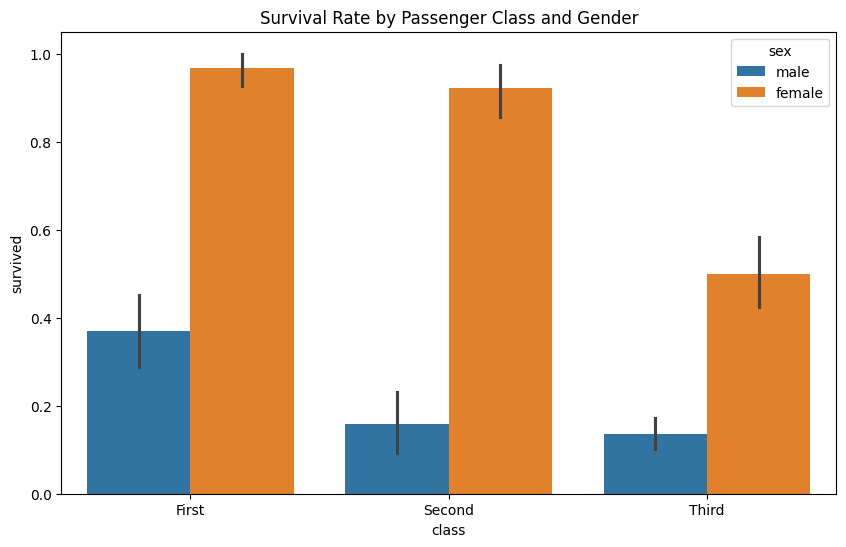

In [65]:
# histogram

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='class', y='survived', hue='sex')
plt.title('Survival Rate by Passenger Class and Gender')
plt.show()

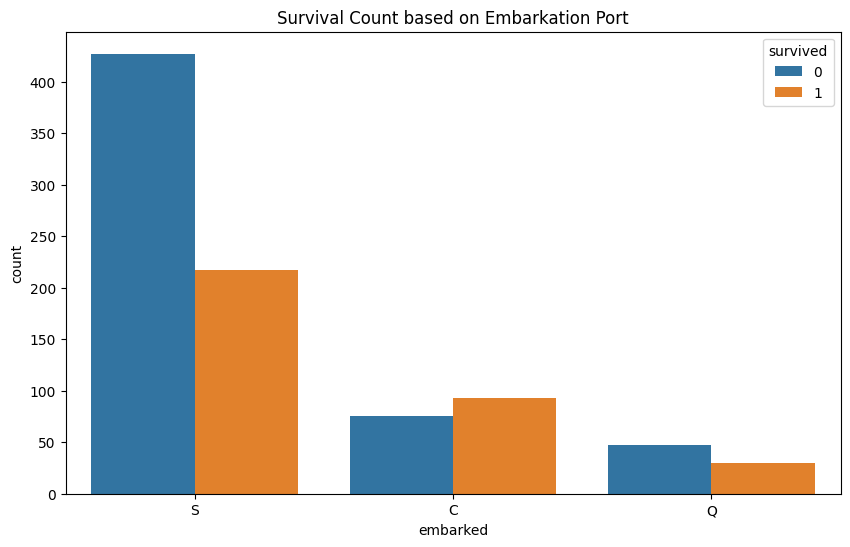

In [66]:
# plot counts

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='embarked', hue='survived')
plt.title('Survival Count based on Embarkation Port')
plt.show()

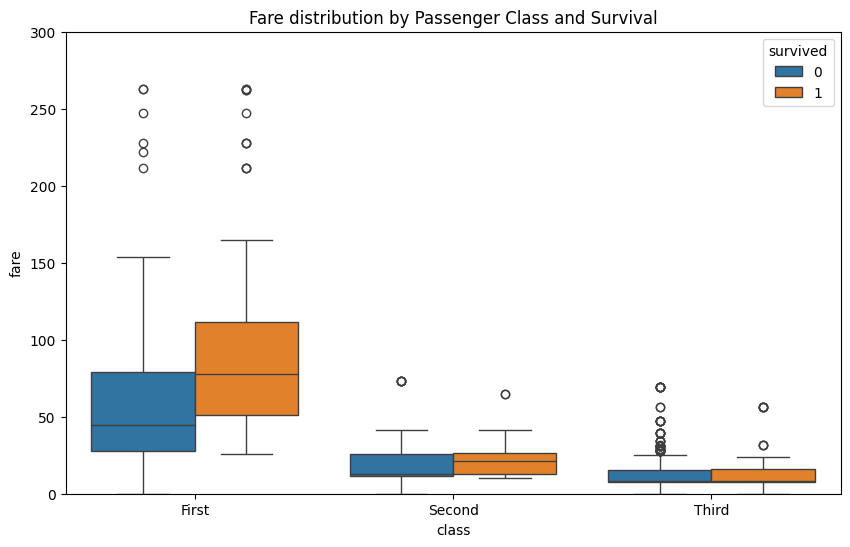

In [67]:
# perhaps your most important plot is boxplot! Take any numerical attribute and plot it along your class
# what do we see in a boxplot?

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='class', y='fare', hue='survived')
plt.ylim(0, 300)  # Limiting y-axis to 300 for better visualization
plt.title('Fare distribution by Passenger Class and Survival')
plt.show()

Text(0.5, 0, 'Fare')

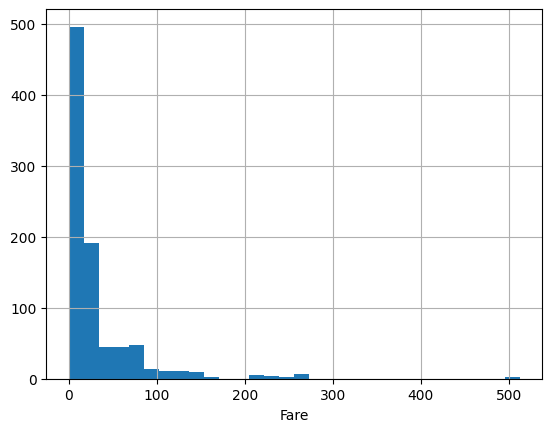

In [68]:
df['fare'].hist(bins=30)
plt.xlabel('Fare')

In [69]:
# It looks like fare has outliers. Let's find them.
# https://www.geeksforgeeks.org/blogs/anomaly-detection-techniques/
from numpy import percentile, where, unique

Q1 = percentile(df['fare'], 25, axis=0)
Q3 = percentile(df['fare'], 75, axis=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies = where((df['fare'] < lower_bound) | (df['fare'] > upper_bound))
unique_anomalies = unique(anomalies[0])
print("Anomalies detected at indices (IQR):", unique_anomalies)

Anomalies detected at indices (IQR): [  1  27  31  34  52  61  62  72  88 102 118 120 124 139 151 159 180 195
 201 215 218 224 230 245 256 257 258 262 268 269 275 290 291 297 299 305
 306 307 310 311 318 319 324 325 332 334 336 337 341 366 369 373 375 377
 380 385 390 393 412 435 438 445 453 484 486 496 498 504 505 520 527 537
 540 544 550 557 558 581 585 587 591 609 627 641 645 655 659 660 665 679
 681 689 698 700 708 716 730 737 741 742 745 759 763 765 779 789 792 802
 820 829 835 846 849 856 863 879]


In [70]:
# Let's calculate the outliners using Local Outlier Factor

from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor(n_neighbors=15)
clf.fit_predict(df[['fare', 'survived']])

# outlier have a larger negative value
df["negative_outlier_factor"] = clf.negative_outlier_factor_
df[df.negative_outlier_factor < -1.5].index


/DockerShare/.pyenv/versions/3.13.7/lib/python3.13/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Index([  0,  14,  19,  22,  36,  54,  59,  67,  71,  75,
       ...
       840, 843, 845, 852, 855, 860, 861, 866, 872, 875],
      dtype='int64', length=170)

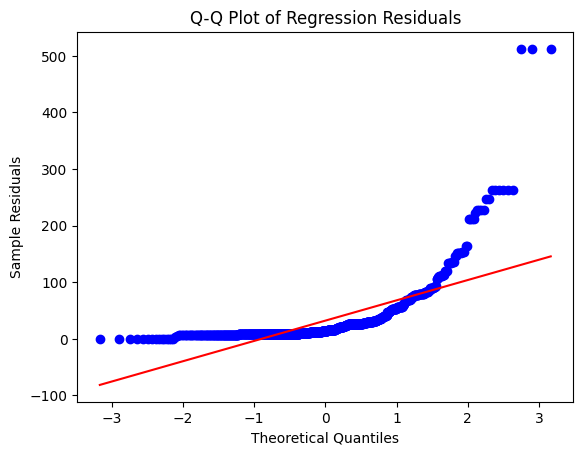

In [71]:
# Sanity check: Q-Q plot to check if errors are normally distributed

stats.probplot(df['fare'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot of Regression Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Residuals")
plt.show()

In [72]:
# quick data aggregations using "groupby"

df.groupby('class')['age'].mean()

/tmp/ipykernel_2971/2033832619.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('class')['age'].mean()


class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64

In [73]:
# data preparation for classification: check for collinearity in input data

df[['survived', 'alive']].value_counts()

# Warning: Survived and Alive are proxy of each other

survived  alive
0         no       549
1         yes      342
Name: count, dtype: int64

In [74]:
# data preparation for classification (using "survived" as target variable)

from sklearn import preprocessing

X = df.drop(['survived', 'alive'], axis=1)
y = df['survived']

pipeline = Pipeline([
    ('encode', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),   # encoding categorical attributes
    ('scaler', preprocessing.RobustScaler()), # minmaxscaler(), standardscaler(), PowerTransformer(), QuantileTransformer(), RobustScaler()
    ('classifier', ensemble.GradientBoostingClassifier(n_estimators=10)) # small number of estimators
])

scores = cross_val_score(pipeline, X, y, cv=10, n_jobs=-1, scoring='f1_macro')  # f1_macro for imbalanced classes
print("Classification accuracy values using 10-fold CV:", scores)   # any negative or extreme values?
print("Mean classification accuracy: %.4f" % scores.mean())

Classification accuracy values using 10-fold CV: [0.72956731 0.76075269 0.72832723 0.86487233 0.82897265 0.76075269
 0.81391876 0.69644307 0.8322459  0.80643758]
Mean classification accuracy: 0.7822


In [75]:
# What are the top 5 features according to chi2 or f_classif? (SelectKBest)
# Make sure we have no missing values for univariate feature selection ...

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   survived                 891 non-null    int64   
 1   pclass                   891 non-null    int64   
 2   sex                      891 non-null    object  
 3   age                      714 non-null    float64 
 4   sibsp                    891 non-null    int64   
 5   parch                    891 non-null    int64   
 6   fare                     891 non-null    float64 
 7   embarked                 889 non-null    object  
 8   class                    891 non-null    category
 9   who                      891 non-null    object  
 10  adult_male               891 non-null    bool    
 11  deck                     203 non-null    category
 12  embark_town              889 non-null    object  
 13  alive                    891 non-null    object  
 14  alone     

In [77]:
# as you can see above, a few columns have missing values: age (float64), deck (category), and embark_town (object)
# we need to impute those missing values as we plan to use univariate feature selection ...

cat_cols = X.select_dtypes(["category", "object"]).columns
num_cols = X.select_dtypes(["number"]).columns

cat_process = Pipeline([
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ("impute", KNNImputer(keep_empty_features=True)),
])

num_process = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", preprocessing.RobustScaler())
])

preprocess = ColumnTransformer([
    ("cat_processes", cat_process, cat_cols),
    ("num_processes", num_process, num_cols)
])

mytop5 = Pipeline([
    ('impute', preprocess),
    ('select', SelectKBest(score_func=f_classif, k=5))  # top 5 features using ANOVA F-value
])

mytop5.fit(X, y)
mytop5.named_steps['select'].get_feature_names_out()

array(['x0', 'x1', 'x10', 'x11', 'x24'], dtype=object)

In [78]:
# Let's see what permutation importance says (another feature selection approach)
# code from https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html

# There's no need to impute values if we use this feature selection approach

pipeline.fit(X, y)
result = permutation_importance(
    pipeline, X, y, n_repeats=10, n_jobs=-1
)

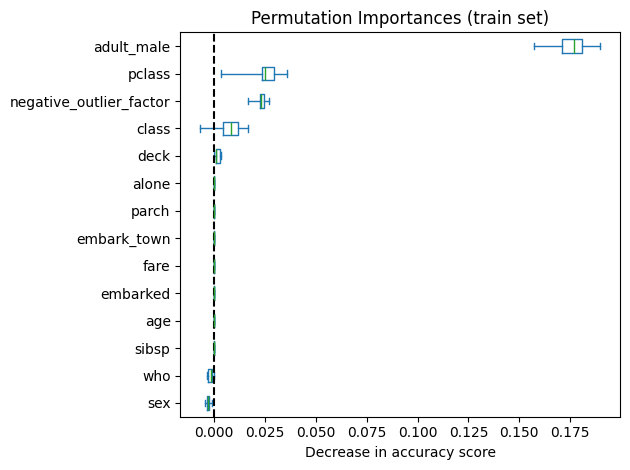

In [79]:
sorted_importances_idx = result.importances_mean.argsort()
importances = DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()